# UTS MACHINE LEARNING

### Nama : Dzhahira Shafa
### NIM : 09011382227150
### Kelas : SKU6

## IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## LOAD DATASET

In [2]:
df = pd.read_csv('credit_customers.csv')
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [3]:
df.tail()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
995,no checking,12.0,existing paid,furniture/equipment,1736.0,<100,4<=X<7,3.0,female div/dep/mar,none,...,real estate,31.0,none,own,1.0,unskilled resident,1.0,none,yes,good
996,<0,30.0,existing paid,used car,3857.0,<100,1<=X<4,4.0,male div/sep,none,...,life insurance,40.0,none,own,1.0,high qualif/self emp/mgmt,1.0,yes,yes,good
997,no checking,12.0,existing paid,radio/tv,804.0,<100,>=7,4.0,male single,none,...,car,38.0,none,own,1.0,skilled,1.0,none,yes,good
998,<0,45.0,existing paid,radio/tv,1845.0,<100,1<=X<4,4.0,male single,none,...,no known property,23.0,none,for free,1.0,skilled,1.0,yes,yes,bad
999,0<=X<200,45.0,critical/other existing credit,used car,4576.0,100<=X<500,unemployed,3.0,male single,none,...,car,27.0,none,own,1.0,skilled,1.0,none,yes,good


In [4]:
df.shape

(1000, 21)

In [5]:
df.columns

Index(['checking_status', 'duration', 'credit_history', 'purpose',
       'credit_amount', 'savings_status', 'employment',
       'installment_commitment', 'personal_status', 'other_parties',
       'residence_since', 'property_magnitude', 'age', 'other_payment_plans',
       'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone',
       'foreign_worker', 'class'],
      dtype='object')

## EXPLORATORY DATA ANALYSIS (EDA)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   checking_status         1000 non-null   object 
 1   duration                1000 non-null   float64
 2   credit_history          1000 non-null   object 
 3   purpose                 1000 non-null   object 
 4   credit_amount           1000 non-null   float64
 5   savings_status          1000 non-null   object 
 6   employment              1000 non-null   object 
 7   installment_commitment  1000 non-null   float64
 8   personal_status         1000 non-null   object 
 9   other_parties           1000 non-null   object 
 10  residence_since         1000 non-null   float64
 11  property_magnitude      1000 non-null   object 
 12  age                     1000 non-null   float64
 13  other_payment_plans     1000 non-null   object 
 14  housing                 1000 non-null   o

In [7]:
# Mengubah object menjadi Category
cat = df.select_dtypes(exclude=[np.number])
for i in list(cat.columns):
    df[i]=df[i].astype('category')

# Cheking Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   float64 
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   float64 
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   float64 
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   float64 
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   float64 
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

In [8]:
# Checking Missing Value

print(df.isnull().sum())

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64


In [9]:
# Spliting Personal Status
new= df['personal_status'].str.split(" ",n=1,expand=True)

#Membuat kolom baru gender dan marital status dari personal status
df['gender']=new[0]
df['marital_status']=new[1]

#Checking Data
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class,gender,marital_status
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,none,own,2.0,skilled,1.0,yes,yes,good,male,single
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,none,own,1.0,skilled,1.0,none,yes,bad,female,div/dep/mar
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,none,own,1.0,unskilled resident,2.0,none,yes,good,male,single
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,none,for free,1.0,skilled,2.0,none,yes,good,male,single
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,none,for free,2.0,skilled,2.0,none,yes,bad,male,single


In [10]:
# Menghapus kolom personal status

df.drop('personal_status',axis=1,inplace=True)

In [11]:
# Cheking categorical features
cat=df.select_dtypes(exclude=[np.number])
cat.columns

Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
       'employment', 'other_parties', 'property_magnitude',
       'other_payment_plans', 'housing', 'job', 'own_telephone',
       'foreign_worker', 'class', 'gender', 'marital_status'],
      dtype='object')

In [12]:
df.describe(include='category')

,checking_status,credit_history,purpose,savings_status,employment,other_parties,property_magnitude,other_payment_plans,housing,job,own_telephone,foreign_worker,class
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,4,5,10,5,5,3,4,3,3,4,2,2,2
top,no checking,existing paid,radio/tv,<100,1<=X<4,none,car,none,own,skilled,none,yes,good
freq,394,530,280,603,339,907,332,814,713,630,596,963,700


In [13]:
df.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


## Visualization

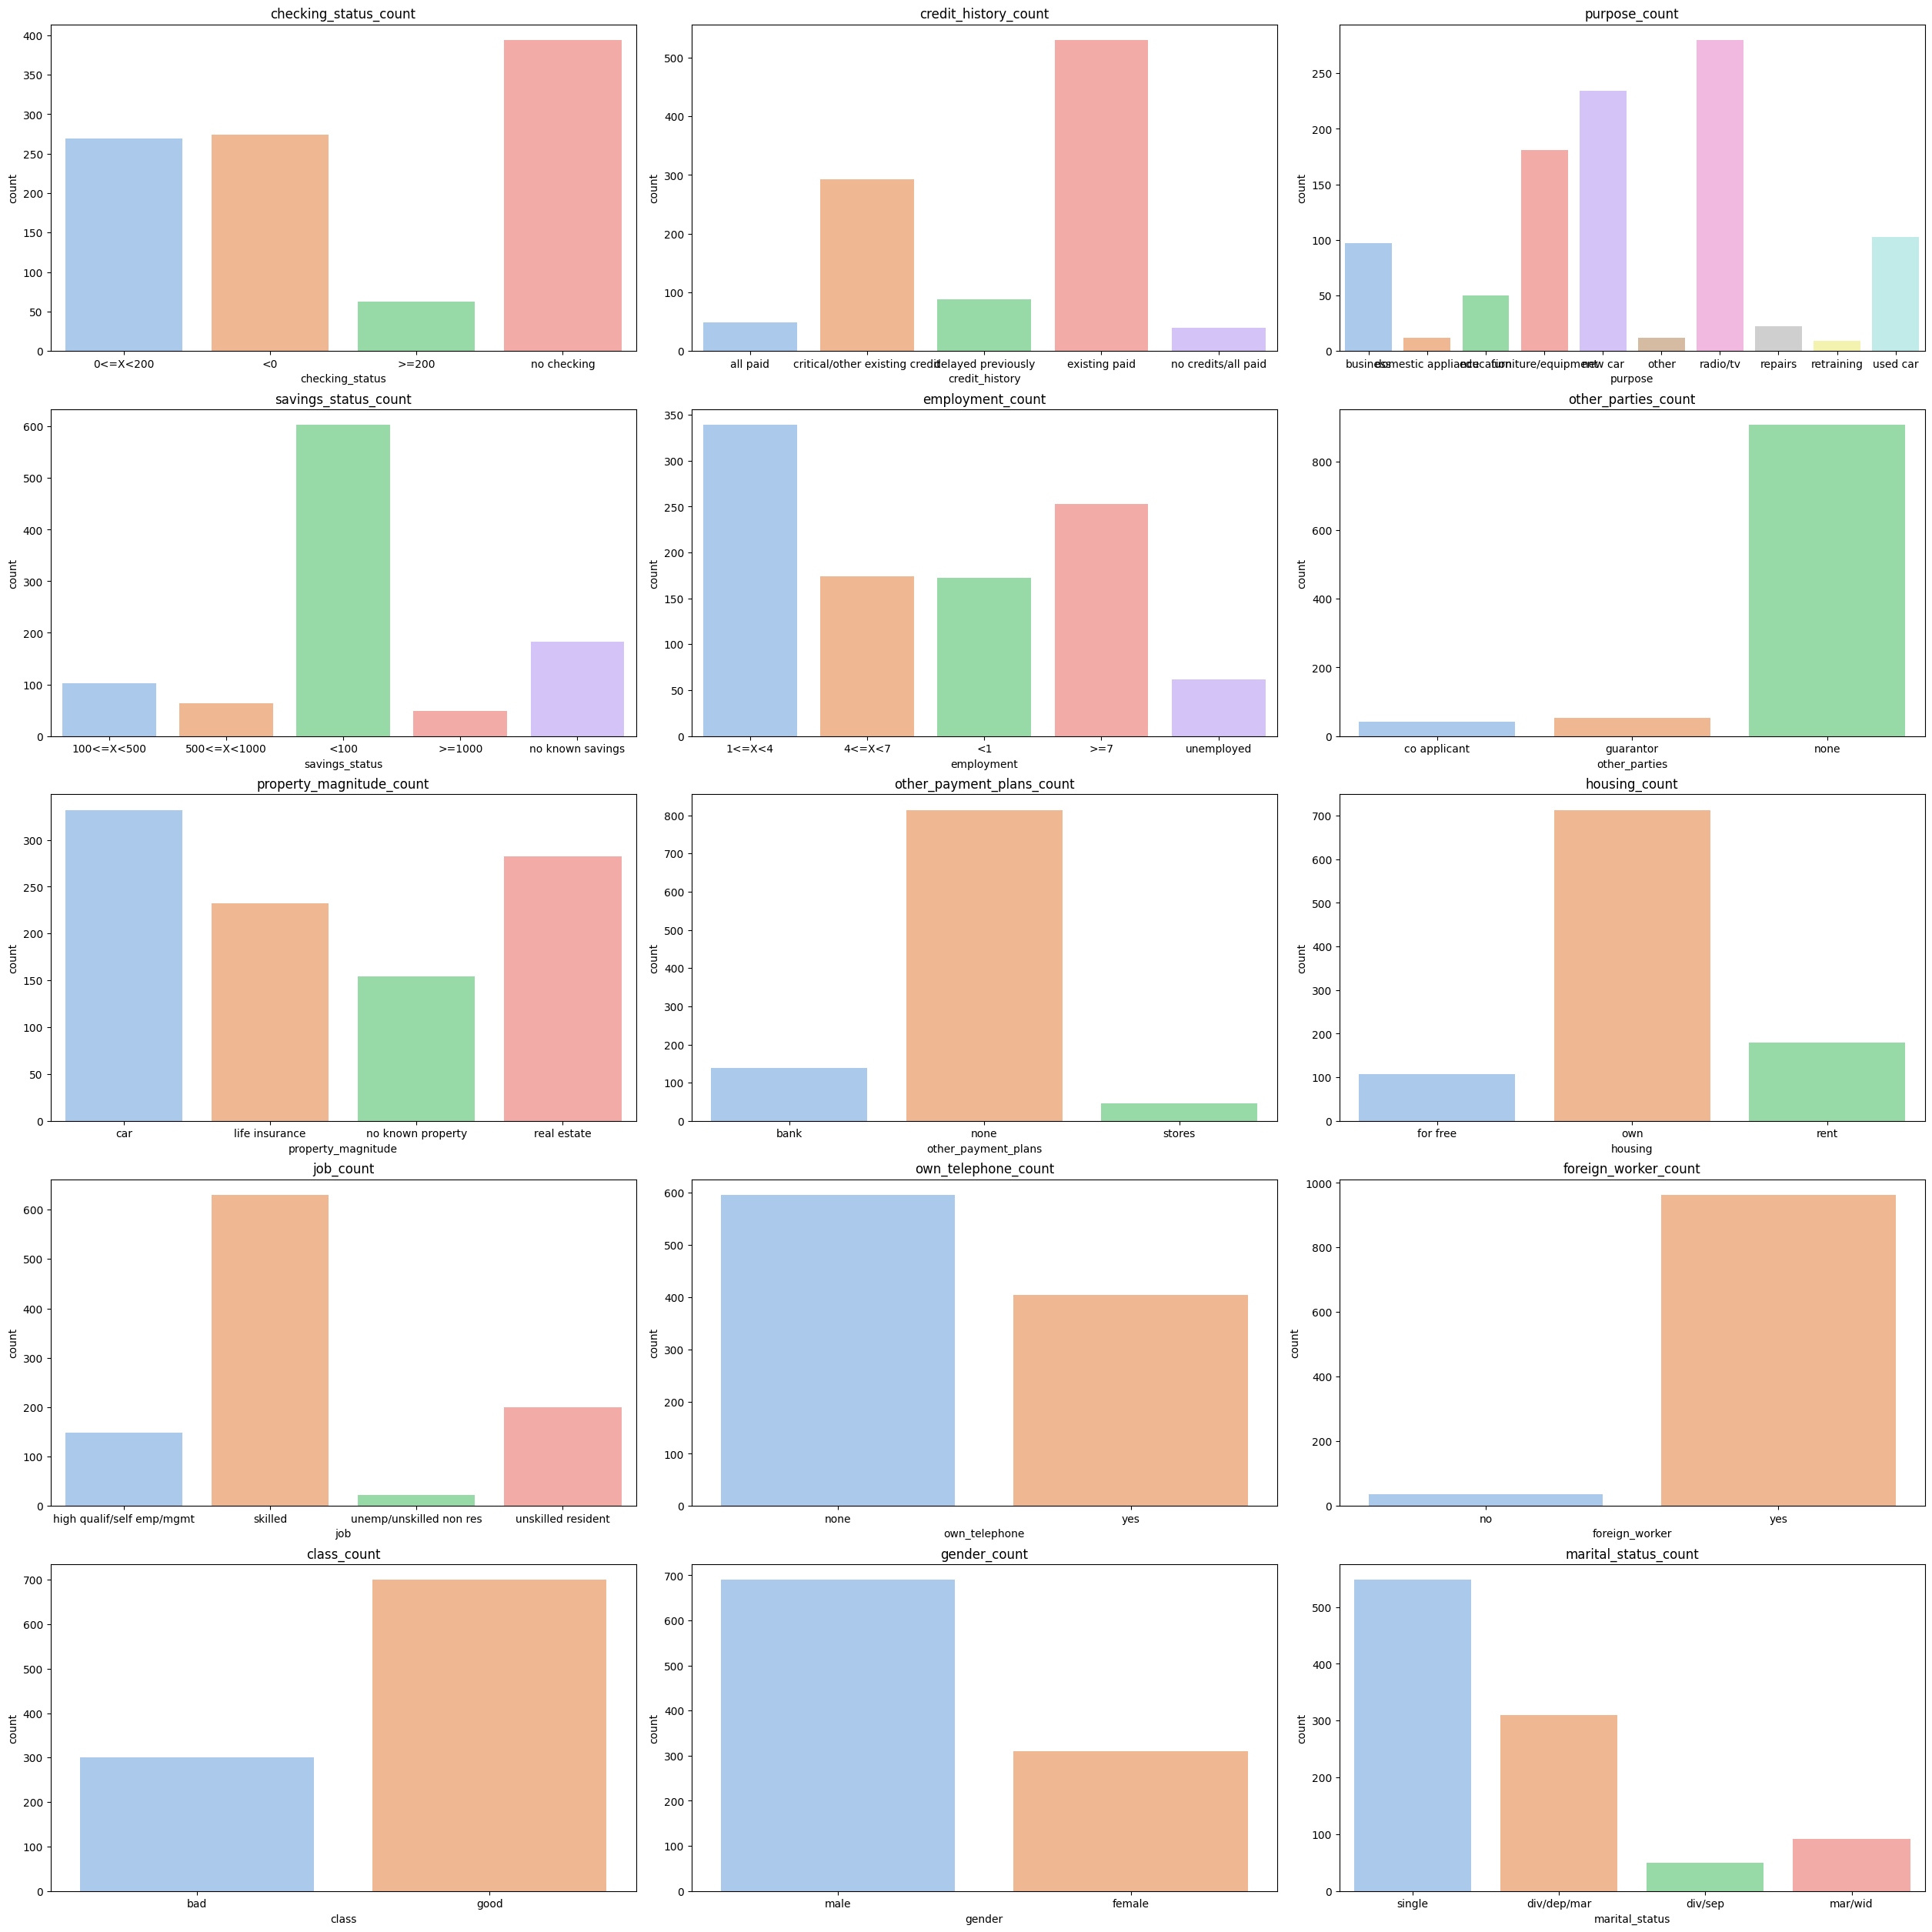

In [14]:
lst=['checking_status', 'credit_history', 'purpose', 'savings_status','employment', 'other_parties', 'property_magnitude','other_payment_plans', 'housing', 'job', 'own_telephone',
     'foreign_worker', 'class', 'gender', 'marital_status']
plt.figure(figsize=(25,25),layout='constrained')
for i in range(len(lst)):
    plt.subplot(5,3,i+1)
    sns.countplot(data=df,x=lst[i],palette='pastel',)
    plt.title(lst[i]+'_count',)
plt.show()

<Figure size 1500x1000 with 0 Axes>

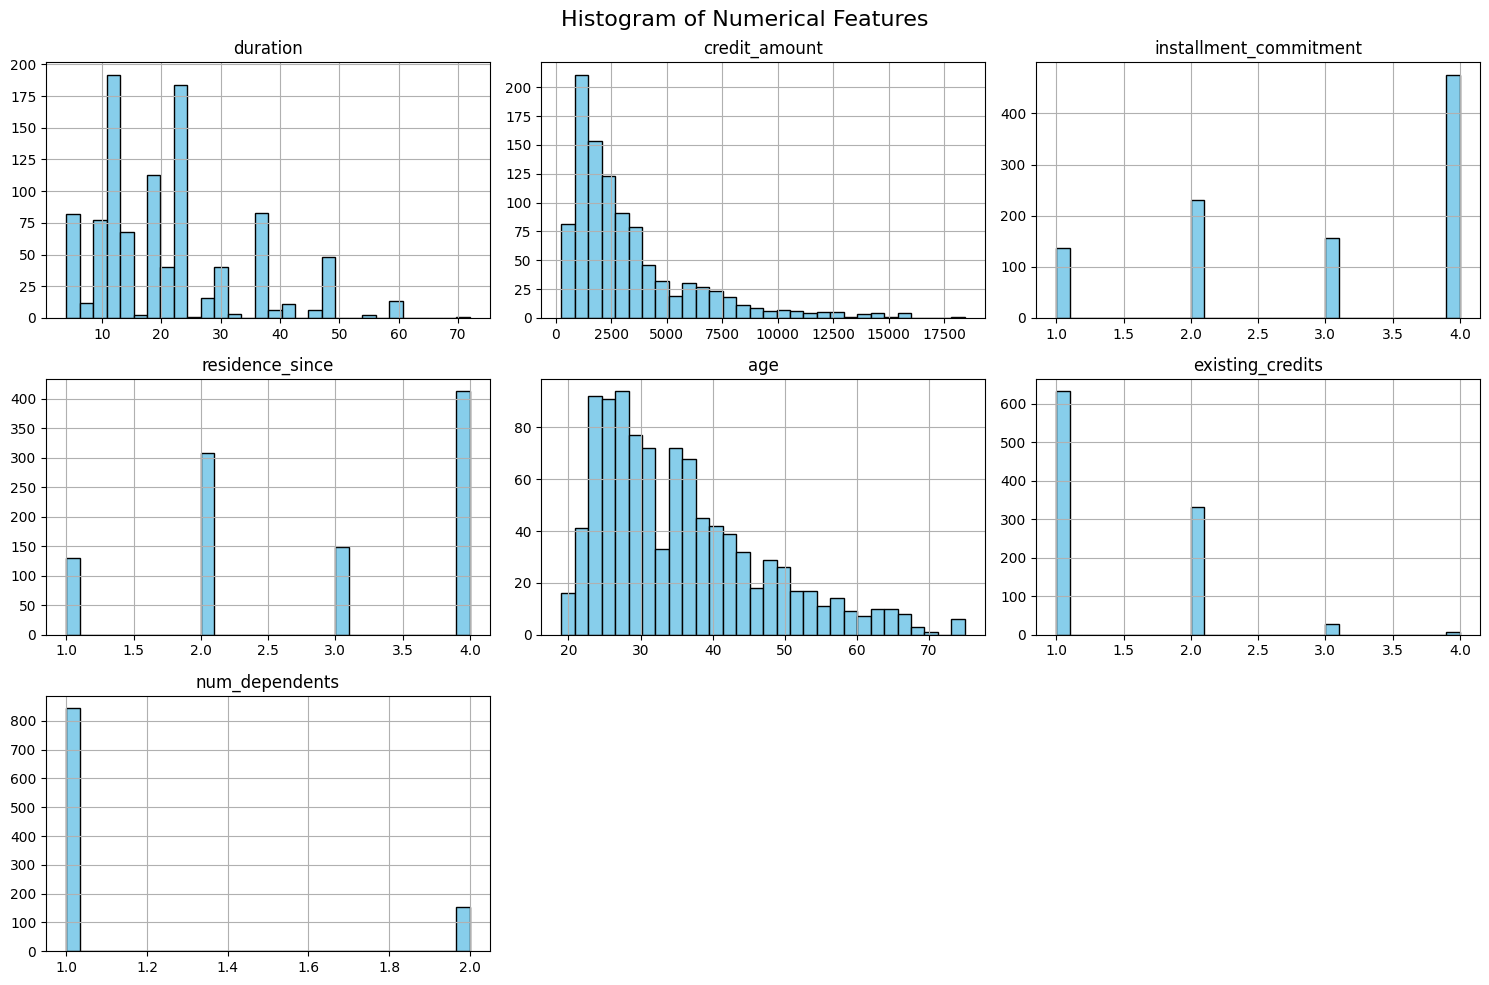

In [15]:
# Pilih hanya fitur numerik
num_cols = df.select_dtypes(include=['number']).columns

# Plot histogram untuk setiap fitur numerik
plt.figure(figsize=(15, 10))
df[num_cols].hist(bins=30, figsize=(15, 10), layout=(len(num_cols)//3 + 1, 3), color='skyblue', edgecolor='black')

plt.suptitle("Histogram of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_20652\961466956.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  cor=df.corr()


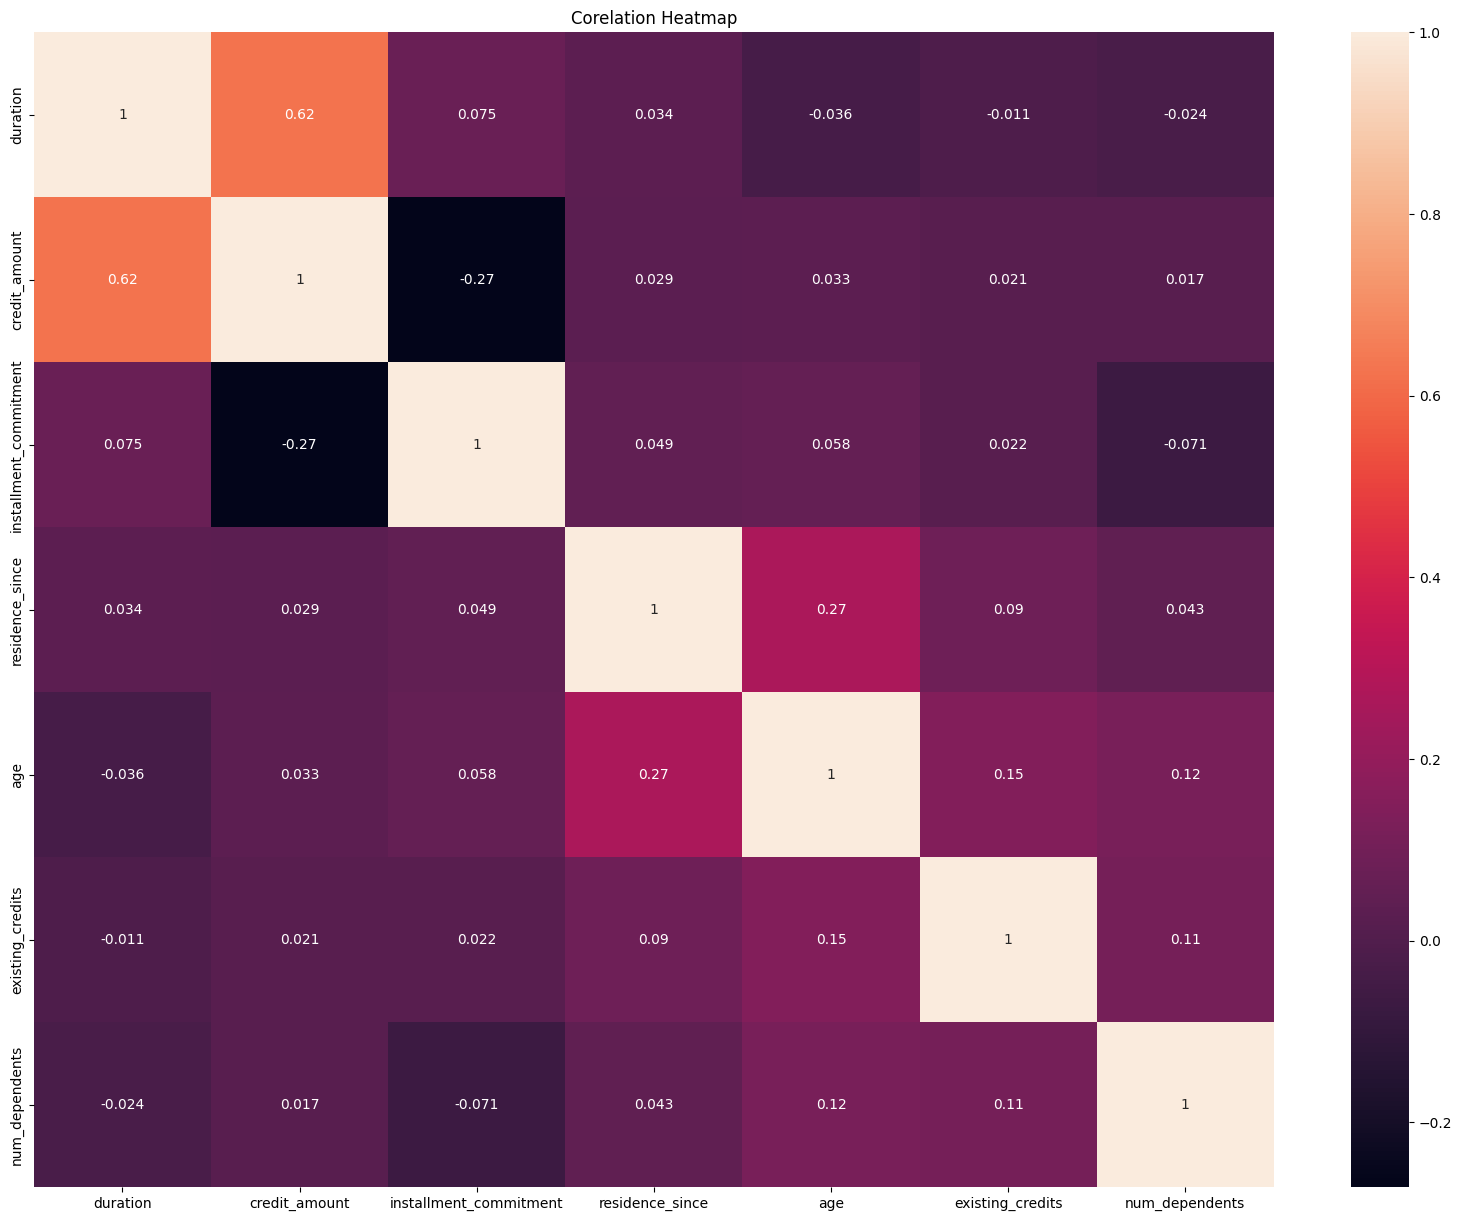

In [16]:
# Fitur Seleksi untuk model Training
cor=df.corr()
plt.figure(figsize=(20,15))
plt.title("Corelation Heatmap")
sns.heatmap(cor,annot=True)
plt.show()

## Label Encoding & Data Scaling

In [17]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

# Label Encoding untuk semua kolom kategorikal
cat_cols = df.select_dtypes(exclude=[np.number]).columns
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Data Scaling dengan MinMaxScaler
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = MinMaxScaler().fit_transform(df[num_cols])

# Tampilkan hasil scaling
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,other_parties,residence_since,...,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class,gender,marital_status
0,0.333333,0.029412,0.25,0.666667,0.050567,1.0,0.75,1.000000,1.0,1.000000,...,0.5,0.5,0.333333,0.333333,0.0,1.0,1.0,1.0,1.0,1.0
1,0.000000,0.647059,0.75,0.666667,0.313690,0.5,0.00,0.333333,1.0,0.333333,...,0.5,0.5,0.000000,0.333333,0.0,0.0,1.0,0.0,0.0,0.0
2,1.000000,0.117647,0.25,0.222222,0.101574,0.5,0.25,0.333333,1.0,0.666667,...,0.5,0.5,0.000000,1.000000,1.0,0.0,1.0,1.0,1.0,1.0
3,0.333333,0.558824,0.75,0.333333,0.419941,0.5,0.25,0.333333,0.5,1.000000,...,0.5,0.0,0.000000,0.333333,1.0,0.0,1.0,1.0,1.0,1.0
4,0.333333,0.294118,0.50,0.444444,0.254209,0.5,0.00,0.666667,1.0,1.000000,...,0.5,0.0,0.333333,0.333333,1.0,0.0,1.0,0.0,1.0,1.0


## Model Training

In [18]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold,KFold,train_test_split,cross_val_score,cross_val_predict
from sklearn.ensemble import RandomForestClassifier

In [19]:
sc = StandardScaler()
x = df.drop(columns=["class"])  
y = df["class"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 
x_train = sc.fit_transform(x_train) 
x_test = sc.transform(x_test)

## Random Forest



Accuracy :  0.755
F1 Score :  0.839344262295082
Classification Report :
               precision    recall  f1-score   support

         0.0       0.64      0.39      0.48        59
         1.0       0.78      0.91      0.84       141

    accuracy                           0.76       200
   macro avg       0.71      0.65      0.66       200
weighted avg       0.74      0.76      0.73       200



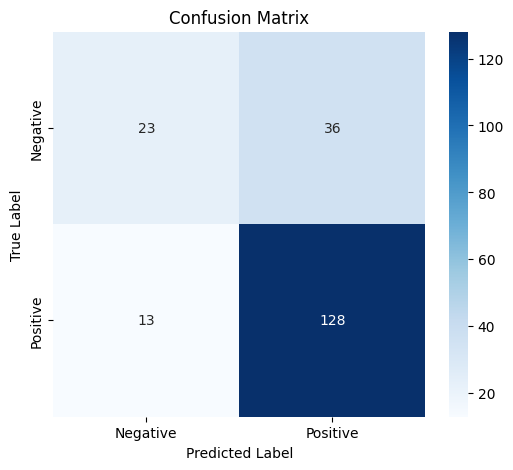

In [20]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,f1_score,precision_score
from sklearn import metrics

rf = RandomForestClassifier() 
rf.fit(x_train, y_train) 
y_pred_rf = rf.predict(x_test) 
conf_rf =confusion_matrix(y_test,y_pred_rf)
clf_rf =classification_report(y_test,y_pred_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test,y_pred_rf)

print('\n')
print('Accuracy : ',acc_rf)
print('F1 Score : ',f1_rf)
print(10*'=====')
print('Classification Report :\n',clf_rf)
print(10*'=====')
plt.figure(figsize=(6, 5))
sns.heatmap(conf_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Decision Tree



Accuracy :  0.705
F1 Score :  0.7885304659498208
Classification Report :
               precision    recall  f1-score   support

         0.0       0.50      0.53      0.51        59
         1.0       0.80      0.78      0.79       141

    accuracy                           0.70       200
   macro avg       0.65      0.65      0.65       200
weighted avg       0.71      0.70      0.71       200



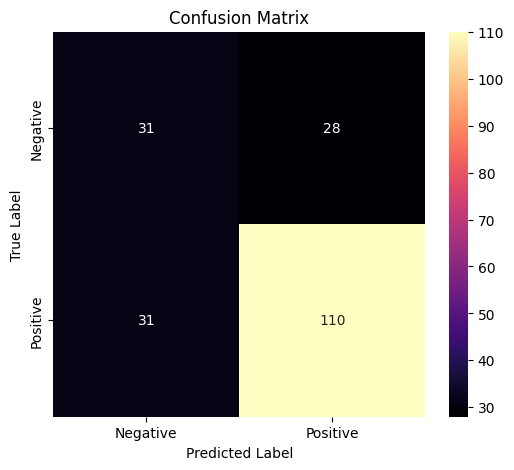

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt =DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)

conf_dt=confusion_matrix(y_test,y_pred)
acc_dt=accuracy_score(y_test,y_pred)
f1_dt=f1_score(y_test,y_pred)
clf_dt=classification_report(y_test,y_pred)

print('\n')
print('Accuracy : ',acc_dt)
print('F1 Score : ',f1_dt)
print(10*'=====')
print('Classification Report :\n',clf_dt)
print(10*'=====')
plt.figure(figsize=(6, 5))
sns.heatmap(conf_dt, annot=True, fmt="d", cmap="magma", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


## Evaluation and Comparison of Models Using Cross-Validation

RandomForest - F1 Score (Train): Mean=0.710, Min=0.655, Max=0.760, Std=0.034
RandomForest - F1 Score (Test): 0.7261

Decision Tree - F1 Score (Train): Mean=0.662, Min=0.613, Max=0.750, Std=0.046
Decision Tree - F1 Score (Test): 0.6791



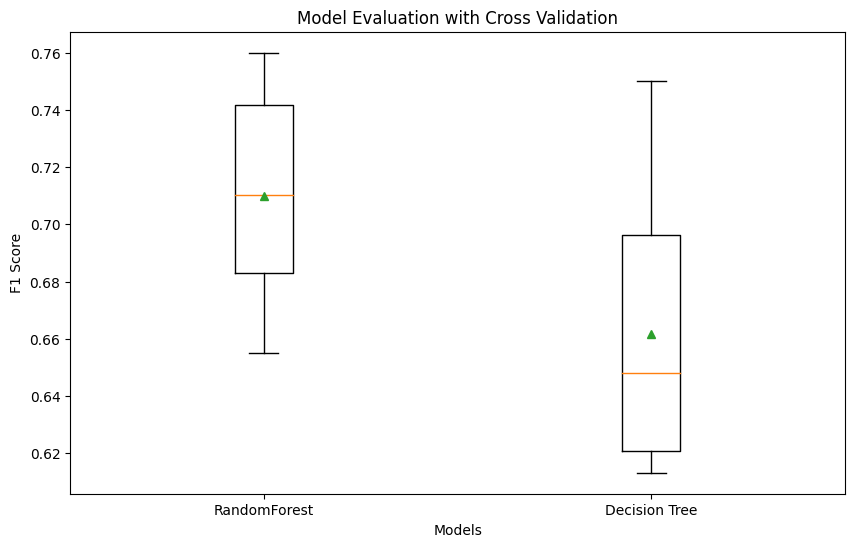

In [22]:
from sklearn.pipeline import Pipeline
import statistics as st

# model yang ingin diuji
models = [RandomForestClassifier(), DecisionTreeClassifier()]
model_names = ["RandomForest", "Decision Tree"]

results, f1_test = [], []

# Cross Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for model, name in zip(models, model_names):
    pipe = Pipeline([('model', model)])
    
    # Evaluasi dengan Cross Validation
    scores = cross_val_score(pipe, x_train, y_train, scoring='f1_weighted', cv=cv, n_jobs=-1)
    results.append(scores)
    
    # Prediksi dengan Cross Validation
    y_pred = cross_val_predict(model, x_train, y_train, cv=cv)
    f1 = f1_score(y_train, y_pred, average='weighted')
    f1_test.append(f1)

    print(f"{name} - F1 Score (Train): Mean={st.mean(scores):.3f}, Min={min(scores):.3f}, Max={max(scores):.3f}, Std={np.std(scores):.3f}")
    print(f"{name} - F1 Score (Test): {f1:.4f}\n")

# Visualisasi Perbandingan Model
plt.figure(figsize=(10,6))
plt.boxplot(results, labels=model_names, showmeans=True)
plt.title("Model Evaluation with Cross Validation")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.show()



## Hyperparameter Tuning and Evaluation Random Forest

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Accuracy: 0.79
F1 Score: 0.7668172043010751

Classification Report:
               precision    recall  f1-score   support

         0.0       0.77      0.41      0.53        59
         1.0       0.79      0.95      0.86       141

    accuracy                           0.79       200
   macro avg       0.78      0.68      0.70       200
weighted avg       0.79      0.79      0.77       200



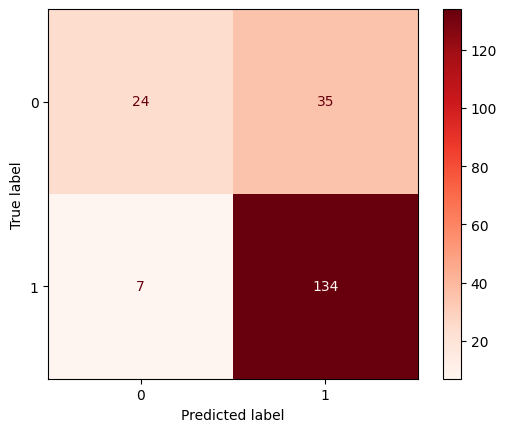

In [26]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter tuning
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

tuned_rf = RandomizedSearchCV(rf, param_grid, n_iter=10, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1, random_state=42)
tuned_rf.fit(x_train, y_train)

# Prediksi
y_pred = tuned_rf.best_estimator_.predict(x_test)

# Evaluasi
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print(10*'=====')
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(10*'=====')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Reds')
plt.show()